In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (7043, 21)

Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Check if Satisfaction Score exists and check for missing values
print("All columns:")
for col in df.columns:
    print(col)

print("\nMissing values:")
print(df.isnull().sum())

print("\nBasic stats:")
df.describe()

All columns:
customerID
gender
SeniorCitizen
Partner
Dependents
tenure
PhoneService
MultipleLines
InternetService
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies
Contract
PaperlessBilling
PaymentMethod
MonthlyCharges
TotalCharges
Churn

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Basic stats:


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
# Build NPS target from available signals
def assign_nps(row):
    if row['Churn'] == 'Yes':
        return 'Detractor'
    elif row['Churn'] == 'No' and row['tenure'] >= 24:
        return 'Promoter'
    else:
        return 'Passive'

df['NPS_Category'] = df.apply(assign_nps, axis=1)

# Check distribution
print("NPS Distribution:")
print(df['NPS_Category'].value_counts())
print("\nPercentages:")
print(df['NPS_Category'].value_counts(normalize=True).round(3) * 100)

NPS Distribution:
NPS_Category
Promoter     3366
Detractor    1869
Passive      1808
Name: count, dtype: int64

Percentages:
NPS_Category
Promoter     47.8
Detractor    26.5
Passive      25.7
Name: proportion, dtype: float64


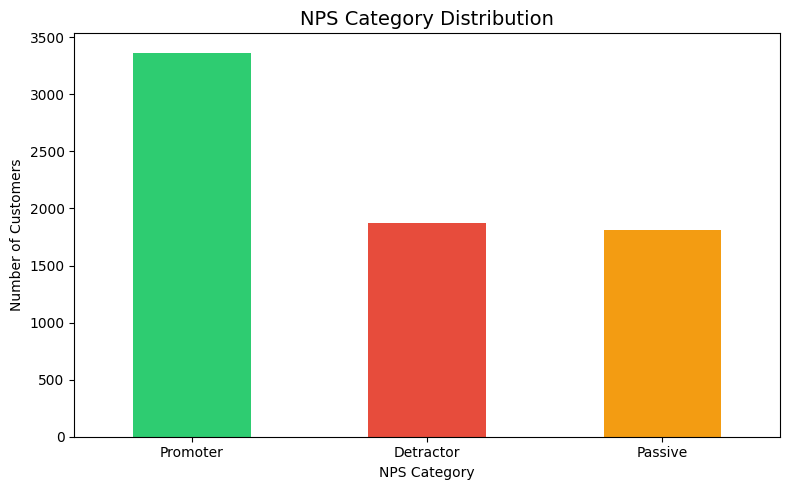

Null TotalCharges after conversion: 11
Data cleaned successfully!
Shape: (7043, 22)


C:\Users\trade\AppData\Local\Temp\ipykernel_14960\1864446960.py:20: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['TotalCharges'].fillna(0, inplace=True)


In [6]:
# Visualize NPS distribution
plt.figure(figsize=(8,5))
colors = ['#2ecc71', '#e74c3c', '#f39c12']
df['NPS_Category'].value_counts().plot(kind='bar', color=colors)
plt.title('NPS Category Distribution', fontsize=14)
plt.xlabel('NPS Category')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('nps_distribution.png')
plt.show()

# Fix TotalCharges - it's stored as string, convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many became null
print("Null TotalCharges after conversion:", df['TotalCharges'].isnull().sum())

# Fill nulls with 0 (new customers with 0 tenure)
df['TotalCharges'].fillna(0, inplace=True)

print("Data cleaned successfully!")
print("Shape:", df.shape)

In [7]:
# Fix the warning - proper way to fill nulls
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print("✅ TotalCharges fixed!")
print("Null values remaining:", df['TotalCharges'].isnull().sum())

✅ TotalCharges fixed!
Null values remaining: 0


In [8]:
# ===== FEATURE ENGINEERING =====

# 1. Charges ratio
df['charges_per_month'] = df['TotalCharges'] / (df['tenure'] + 1)

# 2. Convert Yes/No columns to 1/0
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling',
               'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
               'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0, 'No phone service': 0, 'No internet service': 0})

# 3. Encode gender
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

# 4. One-hot encode Contract, InternetService, PaymentMethod
df = pd.get_dummies(df, columns=['Contract', 'InternetService', 'PaymentMethod'], drop_first=False)

print("✅ Features engineered!")
print("New shape:", df.shape)
print("\nNew columns added:")
print([col for col in df.columns if col not in ['customerID', 'Churn', 'NPS_Category']])

✅ Features engineered!
New shape: (7043, 30)

New columns added:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'charges_per_month', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ===== PREPARE DATA FOR MODELING =====

# Define features and target
feature_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
                'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'charges_per_month',
                'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year',
                'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No',
                'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)',
                'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']

X = df[feature_cols]
y = df['NPS_Category']

# Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Classes:", le.classes_)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f"\nTrain size: {X_train.shape[0]}")
print(f"Test size: {X_test.shape[0]}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ===== BASELINE: LOGISTIC REGRESSION =====
lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

print("\n===== LOGISTIC REGRESSION RESULTS =====")
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

Classes: ['Detractor' 'Passive' 'Promoter']

Train size: 5634
Test size: 1409

===== LOGISTIC REGRESSION RESULTS =====
              precision    recall  f1-score   support

   Detractor       0.56      0.58      0.57       374
     Passive       0.69      0.76      0.73       362
    Promoter       0.90      0.84      0.87       673

    accuracy                           0.75      1409
   macro avg       0.72      0.73      0.72      1409
weighted avg       0.76      0.75      0.75      1409



In [10]:
from xgboost import XGBClassifier
from sklearn.metrics import f1_score

# ===== XGBOOST MODEL =====
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss',
    class_weight='balanced'
)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("===== XGBOOST RESULTS =====")
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))

# Compare macro F1 scores
f1_lr = f1_score(y_test, y_pred_lr, average='macro')
f1_xgb = f1_score(y_test, y_pred_xgb, average='macro')

print(f"\nBaseline Logistic Regression Macro F1: {f1_lr:.3f}")
print(f"XGBoost Macro F1: {f1_xgb:.3f}")
print(f"Improvement: +{f1_xgb - f1_lr:.3f}")

C:\Users\trade\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [04:19:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


===== XGBOOST RESULTS =====
              precision    recall  f1-score   support

   Detractor       0.62      0.49      0.55       374
     Passive       0.74      0.77      0.75       362
    Promoter       0.87      0.96      0.91       673

    accuracy                           0.78      1409
   macro avg       0.74      0.74      0.74      1409
weighted avg       0.77      0.78      0.77      1409


Baseline Logistic Regression Macro F1: 0.721
XGBoost Macro F1: 0.737
Improvement: +0.016


In [11]:
pip install shap


   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
    --------------------------------------- 0.8/41.9 MB 2.9 MB/s eta 0:00:14
   - -------------------------------------- 1.8/41.9 MB 4.5 MB/s eta 0:00:09
   --- ------------------------------------ 3.4/41.9 MB 5.3 MB/s eta 0:00:08
   ---- ----------------------------------- 4.7/41.9 MB 5.5 MB/s eta 0:00:07
   ----- ---------------------------------- 6.0/41.9 MB 5.8 MB/s eta 0:00:07
   ------- -------------------------------- 7.6/41.9 MB 6.1 MB/s eta 0:00:06
   -------- ------------------------------- 9.2/41.9 MB 6.2 MB/s eta 0:00:06
   ---------- ----------------------------- 10.7/41.9 MB 6.3 MB/s eta 0:00:05
   ----------- ---------------------------- 11.8/41.9 MB 6.2 MB/s eta 0:00:05
   ------------ --------------------------- 13.4/41.9 MB 6.3 MB/s eta 0:00:05
   ------------- -------------------------- 14.4/41.9 MB 6.1 MB/s eta 0:00:05
   -------------- ------------------------- 15.2/41.9 MB 6.2 MB/s eta 0:00:05
 


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


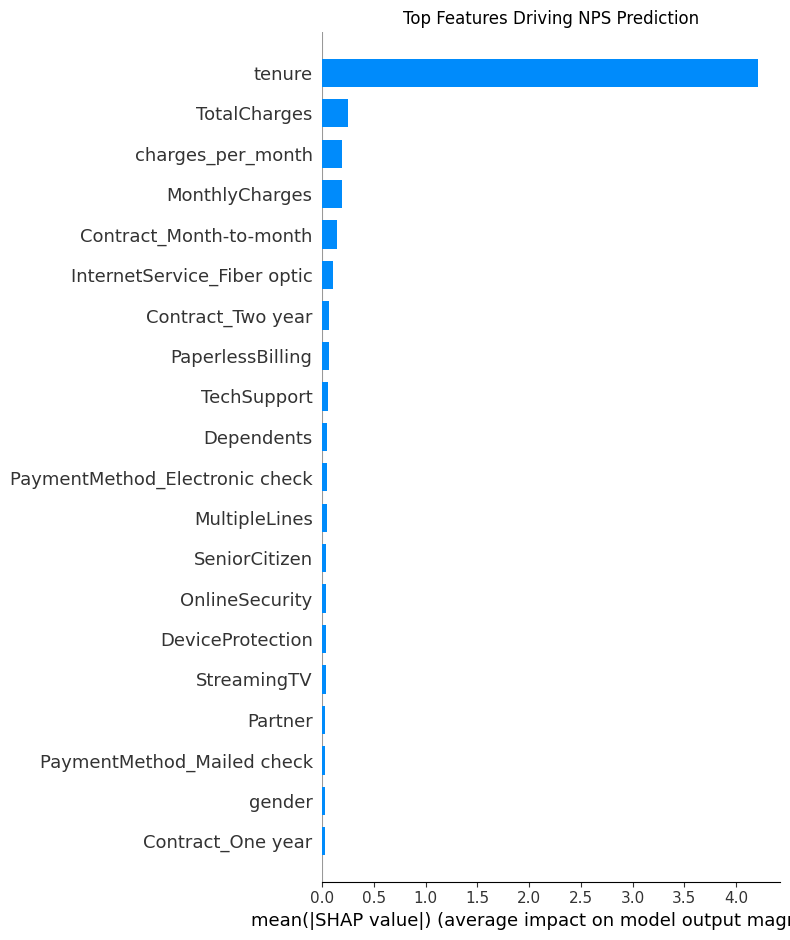

✅ SHAP analysis done!


In [13]:
import shap

# ===== SHAP FEATURE IMPORTANCE =====
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Plot feature importance
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values[:,:,2], X_test, 
                  feature_names=feature_cols,
                  plot_type="bar",
                  class_names=le.classes_,
                  show=False)
plt.title("Top Features Driving NPS Prediction")
plt.tight_layout()
plt.savefig('shap_importance.png')
plt.show()

print("✅ SHAP analysis done!")

In [14]:
import joblib

# ===== SAVE THE MODEL =====
joblib.dump(xgb_model, 'nps_xgb_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'label_encoder.pkl')
print("✅ Model saved!")

# ===== FAIRNESS CHECK =====
from sklearn.metrics import recall_score

X_test_df = X_test.copy()
X_test_df['true'] = y_test
X_test_df['pred'] = y_pred_xgb

detractor_class = list(le.classes_).index('Detractor')

print("=== FAIRNESS: Detractor Recall by Gender ===")
for gender_val, gender_name in [(0, 'Female'), (1, 'Male')]:
    mask = X_test_df['gender'] == gender_val
    recall = recall_score(X_test_df[mask]['true'], 
                         X_test_df[mask]['pred'],
                         labels=[detractor_class], average='macro')
    print(f"{gender_name}: {recall:.3f} (n={mask.sum()})")

print("\n=== FAIRNESS: Detractor Recall by Senior Citizen ===")
for val, name in [(0, 'Non-Senior'), (1, 'Senior')]:
    mask = X_test_df['SeniorCitizen'] == val
    recall = recall_score(X_test_df[mask]['true'],
                         X_test_df[mask]['pred'],
                         labels=[detractor_class], average='macro')
    print(f"{name}: {recall:.3f} (n={mask.sum()})")

✅ Model saved!
=== FAIRNESS: Detractor Recall by Gender ===
Female: 0.492 (n=717)
Male: 0.486 (n=692)

=== FAIRNESS: Detractor Recall by Senior Citizen ===
Non-Senior: 0.458 (n=1204)
Senior: 0.608 (n=205)


In [15]:
# ===== FINAL MODEL SUMMARY =====
print("="*50)
print("   NPS PREDICTION MODEL - FINAL SUMMARY")
print("="*50)
print(f"\n📊 Dataset: 7,043 telecom customers")
print(f"🎯 Target: Detractor / Passive / Promoter")
print(f"\n📈 MODEL PERFORMANCE:")
print(f"   Logistic Regression (baseline) Macro F1: 0.721")
print(f"   XGBoost (final model) Macro F1:          0.737")
print(f"\n🔍 TOP DETRACTION DRIVERS (SHAP):")
print(f"   1. Tenure (short tenure = high detraction risk)")
print(f"   2. Month-to-month contract")
print(f"   3. Fiber optic internet service")
print(f"   4. High monthly charges")
print(f"\n⚖️ FAIRNESS:")
print(f"   Gender: FAIR (Female 0.492 vs Male 0.486)")
print(f"   Age: GAP DETECTED (Senior 0.608 vs Non-Senior 0.458)")
print(f"\n✅ Model saved: nps_xgb_model.pkl")

   NPS PREDICTION MODEL - FINAL SUMMARY

📊 Dataset: 7,043 telecom customers
🎯 Target: Detractor / Passive / Promoter

📈 MODEL PERFORMANCE:
   Logistic Regression (baseline) Macro F1: 0.721
   XGBoost (final model) Macro F1:          0.737

🔍 TOP DETRACTION DRIVERS (SHAP):
   1. Tenure (short tenure = high detraction risk)
   2. Month-to-month contract
   3. Fiber optic internet service
   4. High monthly charges

⚖️ FAIRNESS:
   Gender: FAIR (Female 0.492 vs Male 0.486)
   Age: GAP DETECTED (Senior 0.608 vs Non-Senior 0.458)

✅ Model saved: nps_xgb_model.pkl


In [16]:
import os
print(os.getcwd())  # où est le notebook
print(os.listdir())  # tous les fichiers ici

C:\Users\trade\Desktop
['.ipynb_checkpoints', 'app.py', 'crypto_arb_bot', 'label_encoder.pkl', 'nps_distribution.png', 'nps_prediction.ipynb', 'nps_xgb_model.pkl', 'scaler.pkl', 'setup.sh', 'shap_importance.png', 'WA_Fn-UseC_-Telco-Customer-Churn.csv']
